#Análisis exploratorio del mercado de transferencias de fútbol del verano de 2025.


##Introducción


En este análisis exploratorio revisaremos este dataset que recopila la información sobre cada movimiento que se realizó durante la ventana de transferencias de futbolistas en el verano de 2025.

El dataset muestra datos que describen al jugador, como su nombre , edad y posición que desempeña. Al igual que información sobre su traspaso, esto incluye el país, liga y club al que pertenecía y los mismos datos para su nuevo destino, además de su valor de mercado estimado según TransferMarket, la tarifa si es que se llegó a pagar por el fichaje, finalmente se detalla si la operación fue un préstamo o una venta definitiva.

### Enlace a Kaggle, de donde se obtuvo el dataset: https://www.kaggle.com/datasets/abdellahmaghous/2025-summer-football-transfer-window

### Descripción de datos.


* Name: Nombre del jugador transferido.

* Position: La posición principal en la que juega el futbolista.

* Age: La edad del jugador al momento de la transferencia.

* Market value: El valor estimado del jugador en euros al momento de la transferencia segun TransferMarket.

* Country from: El país de la liga de origen del club que vendió al jugador.

* League from: El nombre de la liga de origen que vendió al futbolista.

* Club from: Nombre del equipo que realizó la venta o préstamo del judador.

* Country to: El país de la liga de destino del club que compró al jugador.

* League to: La liga de destino del club que realizó el movimiento.

* Club to: El nombre del club que compró o recibió al jugador.

* Fee: La tarifa de transferencia real pagada en euros. Representa el costo o ingreso de la transacción. Cuando este valor es igual a 0 significa que el movimiento fue un préstamo o la transferencia fue gratuita.

* loan: Indica si el movimiento fue un prestamo o una transferencia definitiva.

###Pregunta de interés:
¿Qué diferencias se identifican en el perfil promedio de jugador comprado en 3 de las mejores ligas del mundo en comparación con la liga Mexicana?

In [ ]:
#Importar librerias.
import numpy as np
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
pd.set_option('display.float_format', lambda x: '%.2f' % x)

In [ ]:
#Cargar dataset.
from google.colab import files
uploaded = files.upload()

data_summer2025 = next(iter(uploaded))
df = pd.read_csv(data_summer2025)


Saving data_summer2025 (1).csv to data_summer2025 (1) (1).csv


Para comenzar, leemos el dataset y posteriormente visualizamos las primeras 5 filas. Esto con el objetivo de conocer cómo está organizado el dataset.

In [ ]:

print(df.head())

                     name          position age market_value country_from  \
0  Trent Alexander-Arnold        Right-Back  26      €75.00m      England   
1           Matheus Cunha    Second Striker  26      €60.00m      England   
2            Dean Huijsen       Centre-Back  20      €60.00m      England   
3                 Estêvão      Right Winger  18      €60.00m       Brazil   
4       Tijjani Reijnders  Central Midfield  26      €50.00m        Italy   

      league_from                      club_from country_to       league_to  \
0  Premier League                   Liverpool FC      Spain          LaLiga   
1  Premier League        Wolverhampton Wanderers    England  Premier League   
2  Premier League                AFC Bournemouth      Spain          LaLiga   
3         Série A  Sociedade Esportiva Palmeiras    England  Premier League   
4         Serie A                       AC Milan    England  Premier League   

             club_to   fee   loan  
0        Real Madrid  10.0

Realizamos un conteo de las filas y columnas. Al igual que identificamos qué tipo de datos tiene cada columna, esto nos lleva a identificar que 11 columnas son de tipo "object", mientras que la restante es de tipo "boolean".

In [ ]:
#Cantidad de filas y columnas
print(df.shape)

#Tipos de datos y valores nulos
print(df.info())

(1208, 12)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1208 entries, 0 to 1207
Data columns (total 12 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   name          1208 non-null   object
 1   position      1208 non-null   object
 2   age           1208 non-null   object
 3   market_value  1208 non-null   object
 4   country_from  1208 non-null   object
 5   league_from   1208 non-null   object
 6   club_from     1208 non-null   object
 7   country_to    1208 non-null   object
 8   league_to     1208 non-null   object
 9   club_to       1208 non-null   object
 10  fee           1208 non-null   object
 11  loan          1208 non-null   bool  
dtypes: bool(1), object(11)
memory usage: 105.1+ KB
None


###Limpieza de columnas "age", "market value" y "fee", cambio de tipo de dato y calculo de estadísticas básicas.

Se realiza la limpieza de la columna age.

In [ ]:
#Limpieza de la columna age
#Los valores de la columna que no sean numeros se reemplazan por un valor nulo
df['age'] = pd.to_numeric(df['age'], errors='coerce')

#Calcula la media de la columna
age_mean = df['age'].mean()

#Este metodo se encarga de reemplazar los valores nulos agregados por la media de las edades válidas
df['age'] = df['age'].fillna(age_mean)

#Se cambia el tipo de dato de object a entero
df['age'] = df['age'].astype('int64')

#Se muestran los tipos de datos de las columnas
print(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1208 entries, 0 to 1207
Data columns (total 12 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   name          1208 non-null   object
 1   position      1208 non-null   object
 2   age           1208 non-null   int64 
 3   market_value  1208 non-null   object
 4   country_from  1208 non-null   object
 5   league_from   1208 non-null   object
 6   club_from     1208 non-null   object
 7   country_to    1208 non-null   object
 8   league_to     1208 non-null   object
 9   club_to       1208 non-null   object
 10  fee           1208 non-null   object
 11  loan          1208 non-null   bool  
dtypes: bool(1), int64(1), object(10)
memory usage: 105.1+ KB
None


Se calcula la media, mediana y moda de la edad de los jugadores del dataset.

In [ ]:
#Media de edad de los jugadores
mean_age = df['age'].mean()
print(f"Media: {mean_age:.2f}")

#Mediana
median_age = df['age'].median()
print(f"Mediana: {median_age:.2f}")

#Moda
mode_age = df['age'].mode()
print(f"Moda: {mode_age}")

#Desviacion estandar
std_age = df['age'].std()
print(f"Desviación Estándar de la Edad: {std_age:.2f} años")

Media: 24.84
Mediana: 25.00
Moda: 0    26
Name: age, dtype: int64
Desviación Estándar de la Edad: 4.21 años


Se convierte el tipo de dato de la columna "market_value" de objeto a flotante, al igual que se limpia la columna.

In [ ]:
#Conversion del tipo de dato de la columna market_value, al igual que eliminacion del simbolo de euro y modificacion del formato del numero
def clean_and_convert_euro(value):
  value= str(value).lower().strip()

  value=value.replace('€', '')

  if 'm' in value:
    try:
      return float(value.replace('m', '').strip()) * 1_000_000
    except ValueError:
      pass
  elif 'k' in value:
    try:
      return float(value.replace('k', '').strip()) * 1_000
    except ValueError:
      pass
  elif value in ('-', 'unknown', 'free'):
      return 0.0

  try:
      return float(value)
  except ValueError:
      return np.nan

df['market_value'] = df['market_value'].apply(clean_and_convert_euro)

print(df[['market_value']].head())
print("\nVerificación de Tipos de Datos:")
print(df.info())

   market_value
0   75000000.00
1   60000000.00
2   60000000.00
3   60000000.00
4   50000000.00

Verificación de Tipos de Datos:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1208 entries, 0 to 1207
Data columns (total 12 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   name          1208 non-null   object 
 1   position      1208 non-null   object 
 2   age           1208 non-null   int64  
 3   market_value  1208 non-null   float64
 4   country_from  1208 non-null   object 
 5   league_from   1208 non-null   object 
 6   club_from     1208 non-null   object 
 7   country_to    1208 non-null   object 
 8   league_to     1208 non-null   object 
 9   club_to       1208 non-null   object 
 10  fee           1208 non-null   object 
 11  loan          1208 non-null   bool   
dtypes: bool(1), float64(1), int64(1), object(9)
memory usage: 105.1+ KB
None


In [ ]:
#Se calcula la media, mediana y moda de "market value"
mean_market_value = df['market_value'].mean()
print(f"Media: {mean_market_value}")

#Mediana
median_market_value = df['market_value'].median()
print(f"Mediana: {median_market_value}")

#Moda
mode_market_value = df['market_value'].mode()
print(f"Moda: {mode_market_value}")

#Desviacion estandar
std_market_value = df['market_value'].std()
print(f"Desviación Estándar de Valor de Mercado: {std_market_value:.2f} €")


Media: 2320206.953642384
Mediana: 500000.0
Moda: 0   300000.00
Name: market_value, dtype: float64
Desviación Estándar de Valor de Mercado: 6221076.04 €


Se convierte el tipo de dato del "fee" de object a flotante.

In [ ]:

def clean_fee_final_corrected(value):

    value = str(value).lower().strip()

    # Manejo de valores no monetarios (0.0)
    if value in ('unknown','0'):
        return 0.0

    # Manejo de Miles ('k')
    if 'k' in value:
        try:
            return float(value.replace('k', '').strip()) * 1_000
        except ValueError:
            return np.nan

    else:
        try:
            return float(value) * 1_000_000
        except ValueError:
            return np.nan

# Aplicar la función y SOBREESCRIBIR la columna 'fee'
df['fee'] = df['fee'].apply(clean_fee_final_corrected)

print(df[['fee']].head())

          fee
0 10000000.00
1 74200000.00
2 62500000.00
3 34000000.00
4 55000000.00


In [ ]:
#Se calculan estadisticas basicas de "fee"
#Media
mean_fee = df['fee'].mean()
print(f"Media: {mean_fee}")

#Mediana
median_fee = df['fee'].median()
print(f"Mediana: {median_fee}")

#Moda
mode_fee = df['fee'].mode()
print(f"Moda: {mode_fee}")

#Desviacion estandar
std_fee = df['fee'].std()
print(f"Desviación Estándar de Tarifa de Transferencia: {std_fee:,.2f} €")

Media: 1956085.2649006622
Mediana: 0.0
Moda: 0   0.00
Name: fee, dtype: float64
Desviación Estándar de Tarifa de Transferencia: 15,386,573.35 €


In [ ]:
#Identificacion de variables numericas y categoricas
numeric_cols = df.select_dtypes(include=['int64', 'float64']).columns.tolist()
categorical_cols = df.select_dtypes(include=['object', 'bool']).columns.tolist()

print("Variables Numéricas:", numeric_cols)
print("Variables Categóricas:", categorical_cols)

Variables Numéricas: ['age', 'market_value', 'fee']
Variables Categóricas: ['name', 'position', 'country_from', 'league_from', 'club_from', 'country_to', 'league_to', 'club_to', 'loan']


In [ ]:
#Categorizacion de los valores de "market value", con el objetivo de obtener un analisis más solido de la pregunta de interés planteada.
# Mapeo de las posiciones granulares a las cuatro categorías principales
position_map = {
    # Goalkeepers
    'Goalkeeper': 'Goalkeeper',

    # Defenders
    'Centre-Back': 'Defender',
    'Left-Back': 'Defender',
    'Right-Back': 'Defender',
    'Fullback': 'Defender',
    'Sweeper': 'Defender',
    'Defensive Midfield': 'Defender',

    # Midfielders
    'Central Midfield': 'Midfielder',
    'Attacking Midfield': 'Midfielder',
    'Midfielder': 'Midfielder',
    'Left Midfield': 'Midfielder',
    'Right Midfield': 'Midfielder',

    # Forwards
    'Centre-Forward': 'Forward',
    'Striker': 'Forward',
    'Left Winger': 'Forward',
    'Right Winger': 'Forward',
    'Second Striker': 'Forward',
}

# Aplicar el mapeo para crear una nueva columna de posición simplificada
df['position_group'] = df['position'].replace(position_map)

print(df[df['position_group'].isnull()]['position'].unique())
print(df.head())

[]
                     name          position  age  market_value country_from  \
0  Trent Alexander-Arnold        Right-Back   26   75000000.00      England   
1           Matheus Cunha    Second Striker   26   60000000.00      England   
2            Dean Huijsen       Centre-Back   20   60000000.00      England   
3                 Estêvão      Right Winger   18   60000000.00       Brazil   
4       Tijjani Reijnders  Central Midfield   26   50000000.00        Italy   

      league_from                      club_from country_to       league_to  \
0  Premier League                   Liverpool FC      Spain          LaLiga   
1  Premier League        Wolverhampton Wanderers    England  Premier League   
2  Premier League                AFC Bournemouth      Spain          LaLiga   
3         Série A  Sociedade Esportiva Palmeiras    England  Premier League   
4         Serie A                       AC Milan    England  Premier League   

             club_to         fee   loan positio

##Resultados:

###Preguntas respondidas con estadísticas básicas:

De las 3 ligas más competitivas de Europa y México ¿Cúal es la que más invierte dinero en futbolistas y cúal es la que recibe más ingresos por la venta de jugadores?

In [ ]:
#Se visualizan las transferencias realizadas al país México debido a inconsistencias con el nombre asignado a la columna "Liga" del país mencionado.
#Esto con el objetivo de identificar qué clubes son de primera división y comenzar a responder las preguntas planteadas.
COUNTRY_NAME = 'Mexico'

condicion_destino = df['country_to'].str.contains(COUNTRY_NAME, case=False, na=False)

# Filtra el DataFrame usando SOLAMENTE la condición de destino
df_fichados_por_mexico = df[condicion_destino]

# Visualiza las filas resultantes
# El comando .to_string() ayuda a ver todas las filas si son muchas
print(df_fichados_por_mexico.to_string())


                     name            position  age  market_value country_from        league_from                club_from country_to         league_to                club_to        fee   loan position_group
119        Efraín Álvarez        Right Winger   23    5500000.00       Mexico     Without League             Club Tijuana     Mexico    Without League  Deportivo Guadalajara       0.00  False        Forward
134             Pau López          Goalkeeper   30    2500000.00       France            Ligue 1      Olympique Marseille     Mexico    Without League       Deportivo Toluca 4800000.00  False     Goalkeeper
144      Fernando Beltrán    Central Midfield   27    4000000.00       Mexico     Without League    Deportivo Guadalajara     Mexico    Without League           Club León FC 2600000.00  False     Midfielder
145    Agustín Palavecino    Central Midfield   28    4000000.00    Argentina    Torneo Apertura           CA River Plate     Mexico    Without League            Club Necax

In [ ]:
#Se definen los grupos de las ligas europeas a analizar.
big_3_leagues = ['Premier League', 'LaLiga', 'Serie A']
#Se definen los clubes mexicanos de primera division que realizaron compras de futbolistas en verano de 2025
mexican_clubs = [
    'Deportivo Guadalajara', 'Deportivo Toluca', 'Club León FC',
    'Club Necaxa', 'CF Pachuca', 'FC Juárez', 'Puebla FC'
]
ligas_a_comparar = big_3_leagues + ['Liga MX']

EXCLUDE_VALUE = 'without league'
df_limpio = df[df['league_to'] != EXCLUDE_VALUE].copy() # Usar DataFrame limpi

#Calculo de compras
df_limpio['Liga_Gasto'] = df_limpio['league_to']
# Escribir 'Liga MX' en caso de que el club sea mexicano
df_limpio.loc[df_limpio['club_to'].isin(mexican_clubs), 'Liga_Gasto'] = 'Liga MX'

# Agrupar y sumar el gasto, filtrando solo las ligas de interés
gasto_total = df_limpio[df_limpio['Liga_Gasto'].isin(ligas_a_comparar)] \
                     .groupby('Liga_Gasto')['fee'].sum().rename('Gasto Total (Inversión)')

media_gasto = df_limpio[df_limpio['Liga_Gasto'].isin(ligas_a_comparar)].groupby('Liga_Gasto')['fee'].mean().rename('Media Gasto (Inversión)')

#Calculo de ventas
df_limpio['Liga_Ingreso'] = df_limpio['league_from']
# Escribir 'Liga MX' en caso de que el club sea mexicano
df_limpio.loc[df_limpio['club_from'].isin(mexican_clubs), 'Liga_Ingreso'] = 'Liga MX'

# Agrupar y sumar el ingreso, filtrando solo las ligas de interés
ingreso_total = df_limpio[df_limpio['Liga_Ingreso'].isin(ligas_a_comparar)] \
                      .groupby('Liga_Ingreso')['fee'].sum().rename('Ingreso Total (Venta)')
media_ingreso = df_limpio[df_limpio['Liga_Ingreso'].isin(ligas_a_comparar)].groupby('Liga_Ingreso')['fee'].mean().rename('Media Ingreso (Venta)')


df_comparacion = pd.concat([gasto_total, ingreso_total], axis=1).fillna(0)

df_media_comparacion = pd.concat([media_gasto, media_ingreso], axis=1).fillna(0)

print("--- Comparación de Inversión (Gasto) vs. Ingreso Total ---")
print(df_comparacion.map(lambda x: f'€{x:,.0f}'))

print("--- Comparación de Media de Gasto e Ingreso por Fichaje ---")
print(df_media_comparacion.map(lambda x: f'€{x:,.0f}'))

--- Comparación de Inversión (Gasto) vs. Ingreso Total ---
               Gasto Total (Inversión) Ingreso Total (Venta)
LaLiga                    €180,500,000           €70,650,000
Liga MX                    €13,160,000            €4,600,000
Premier League            €673,446,000          €355,576,000
Serie A                   €255,330,000          €752,600,000
--- Comparación de Media de Gasto e Ingreso por Fichaje ---
               Media Gasto (Inversión) Media Ingreso (Venta)
LaLiga                     €10,617,647            €4,415,625
Liga MX                     €1,316,000              €766,667
Premier League             €16,425,512           €11,111,750
Serie A                     €9,456,667           €26,878,571


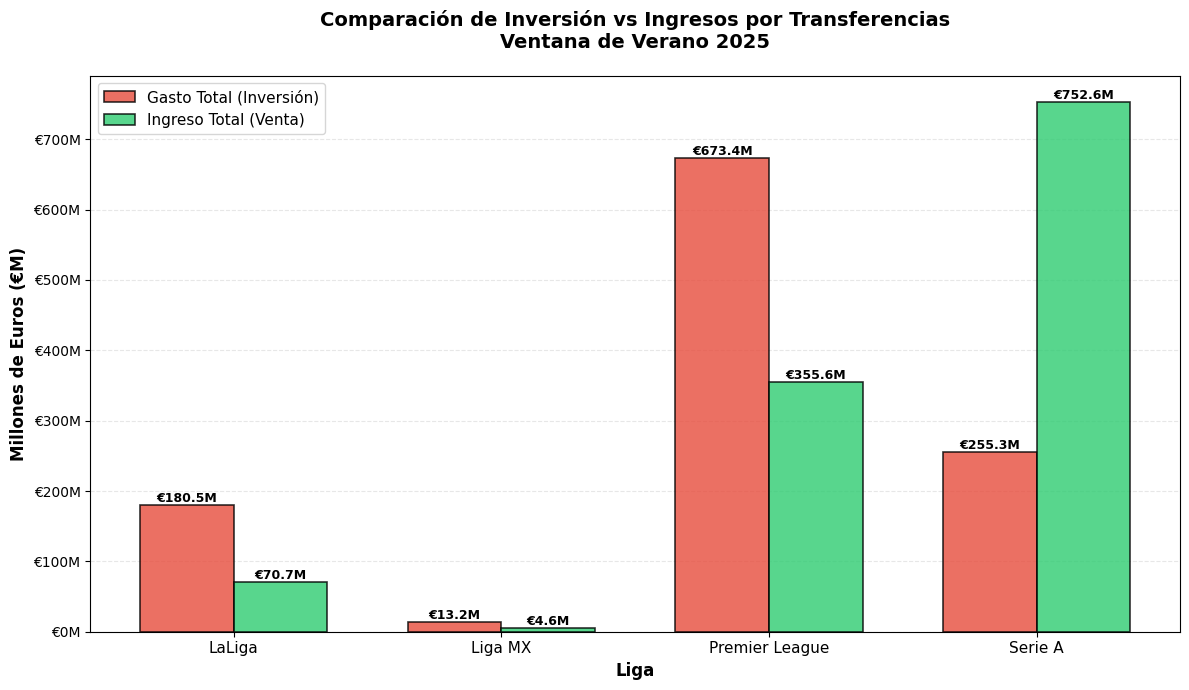

In [ ]:
# Preparar los datos
ligas = df_comparacion.index.tolist()
gastos = df_comparacion['Gasto Total (Inversión)'].values / 1_000_000  # Convertir a millones
ingresos = df_comparacion['Ingreso Total (Venta)'].values / 1_000_000  # Convertir a millones

# Configuración del gráfico
fig, ax = plt.subplots(figsize=(12, 7))

# Posiciones de las barras
x = np.arange(len(ligas))
width = 0.35  # Ancho de las barras

# Crear las barras
barras_gasto = ax.bar(x - width/2, gastos, width, label='Gasto Total (Inversión)',
                      color='#E74C3C', alpha=0.8, edgecolor='black', linewidth=1.2)
barras_ingreso = ax.bar(x + width/2, ingresos, width, label='Ingreso Total (Venta)',
                        color='#2ECC71', alpha=0.8, edgecolor='black', linewidth=1.2)

# Añadir valores encima de las barras
for barras in [barras_gasto, barras_ingreso]:
    for barra in barras:
        height = barra.get_height()
        ax.text(barra.get_x() + barra.get_width()/2., height,
                f'€{height:.1f}M',
                ha='center', va='bottom', fontsize=9, fontweight='bold')

# Personalización
ax.set_xlabel('Liga', fontsize=12, fontweight='bold')
ax.set_ylabel('Millones de Euros (€M)', fontsize=12, fontweight='bold')
ax.set_title('Comparación de Inversión vs Ingresos por Transferencias\nVentana de Verano 2025',
             fontsize=14, fontweight='bold', pad=20)
ax.set_xticks(x)
ax.set_xticklabels(ligas, fontsize=11)
ax.legend(fontsize=11, loc='upper left')

# Grid para mejor lectura
ax.grid(axis='y', alpha=0.3, linestyle='--')
ax.set_axisbelow(True)

# Mejorar el formato del eje Y
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda y, _: f'€{y:.0f}M'))

plt.tight_layout()
plt.show()


¿Qué liga ficha al jugador típico de mayor valor?

Jugador típico: Se define por la mediana del valor de mercado. Es el valor que está justo en la mitad de todos los jugadores fichados por esta liga.

La importancia de conocer esta mediana es porque compensa la volatilidad y el sesgo del mercado de fichajes. Permitirá identificar qué liga tiene un mayor poder adquisitivo constante en sus fichajes, no solo para ciertos jugadores "estrellas".


In [ ]:
big_3_leagues = ['Premier League', 'LaLiga', 'Serie A']
mexican_clubs = [
    'Deportivo Guadalajara', 'Deportivo Toluca', 'Club León FC',
    'Club Necaxa', 'CF Pachuca', 'FC Juárez', 'Puebla FC'
]
ligas_a_comparar = big_3_leagues + ['Liga MX']

EXCLUDE_VALUE = 'without league'
df_limpio = df[df['league_to'] != EXCLUDE_VALUE].copy()

# Crear columna estandarizada 'Liga_Target' para fichajes
df_limpio['Liga_Target'] = df_limpio['league_to']
# Asignar 'Liga MX' a los fichajes realizados por clubes mexicanos
df_limpio.loc[df_limpio['club_to'].isin(mexican_clubs), 'Liga_Target'] = 'Liga MX'

#Filtrar solo las ligas de interés
df_fichajes = df_limpio[df_limpio['Liga_Target'].isin(ligas_a_comparar)]

#Calcular la mediana de 'market_value' y ordenar (DESCENDENTE)
mediana_market_value = df_fichajes.groupby('Liga_Target')['market_value'].median().sort_values(ascending=False)

print("--- Valor de Mercado Mediano (Típico) de Jugadores Fichados ---")
print("La liga con el valor más alto ficha al jugador típico de mayor valor.")
print(mediana_market_value.map(lambda x: f'€{x:,.0f}'))

print("\nConclusión:")
liga_tipica_mas_cara = mediana_market_value.index[0]
mediana_max = mediana_market_value.iloc[0]
print(f"La liga que ficha al jugador típico de mayor valor es: {liga_tipica_mas_cara}, con una mediana de valor de mercado de €{mediana_max:,.0f}.")

--- Valor de Mercado Mediano (Típico) de Jugadores Fichados ---
La liga con el valor más alto ficha al jugador típico de mayor valor.
Liga_Target
Premier League    €10,000,000
Serie A            €8,000,000
LaLiga             €6,000,000
Liga MX            €2,400,000
Name: market_value, dtype: object

Conclusión:
La liga que ficha al jugador típico de mayor valor es: Premier League, con una mediana de valor de mercado de €10,000,000.


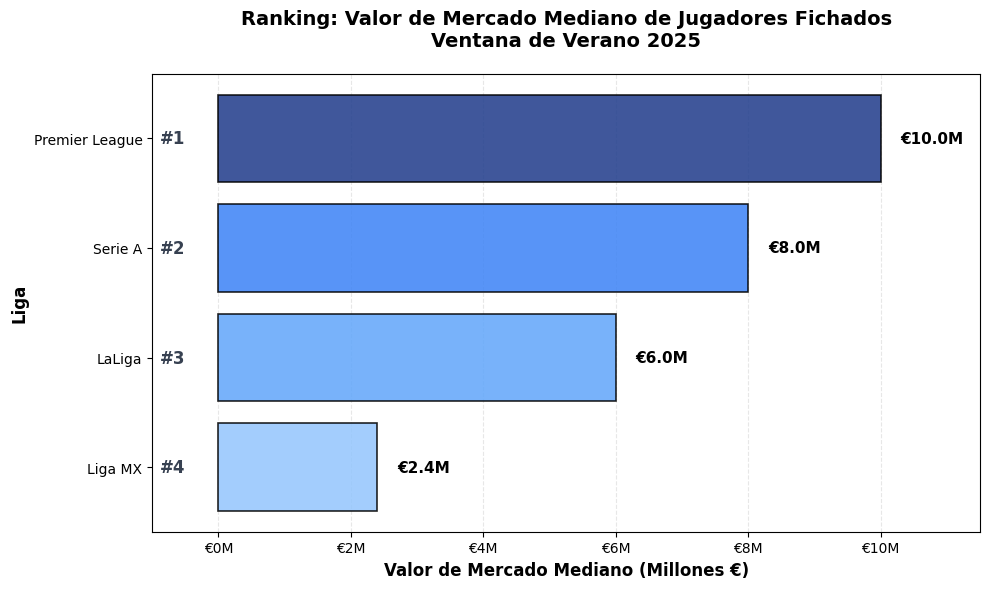

In [ ]:
ligas = mediana_market_value.index.tolist()
valores = mediana_market_value.values / 1_000_000  # Convertir a millones

# Degradado de colores del más intenso al más claro
colores = ['#1e3a8a', '#3b82f6', '#60a5fa', '#93c5fd']

# Configuración del gráfico
fig, ax = plt.subplots(figsize=(10, 6))

# Crear barras horizontales
barras = ax.barh(ligas, valores, color=colores, edgecolor='black',
                 linewidth=1.2, alpha=0.85)

# Añadir valores al final de cada barra
for i, (barra, valor) in enumerate(zip(barras, valores)):
    ax.text(valor + 0.3, i, f'€{valor:.1f}M',
            va='center', fontsize=11, fontweight='bold')

# Añadir ranking numérico al inicio
for i, liga in enumerate(ligas):
    ax.text(-0.5, i, f'#{i+1}', va='center', ha='right',
            fontsize=12, fontweight='bold', color='#374151')

# Personalización
ax.set_xlabel('Valor de Mercado Mediano (Millones €)', fontsize=12, fontweight='bold')
ax.set_ylabel('Liga', fontsize=12, fontweight='bold')
ax.set_title('Ranking: Valor de Mercado Mediano de Jugadores Fichados\nVentana de Verano 2025',
             fontsize=14, fontweight='bold', pad=20)

# Invertir eje Y para que el #1 esté arriba
ax.invert_yaxis()

# Grid vertical para mejor lectura
ax.grid(axis='x', alpha=0.3, linestyle='--')
ax.set_axisbelow(True)

# Formato del eje X
ax.xaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'€{x:.0f}M'))

# Ajustar límites del eje X para dar espacio a las etiquetas
ax.set_xlim(-1, max(valores) * 1.15)

plt.tight_layout()
plt.show()


¿Qué país extranjero es el que más vende jugadores a las 3 grandes ligas de Europa y a México?

In [ ]:
league_countries = {
    'Premier League': 'England',
    'LaLiga': 'Spain',
    'Serie A': 'Italy',
    'Liga MX': 'Mexico'
}
target_leagues = list(league_countries.keys())

#Para almacenar los resultados
results = {}

# Reutilizar el DataFrame limpio de la fila 'without league'
df_limpio = df[df['league_to'] != 'without league'].copy()

#Columna estandarizada 'Liga_Target' para fichajes (destino)
df_limpio['Liga_Target'] = df_limpio['league_to']
mexican_clubs = ['Deportivo Guadalajara', 'Deportivo Toluca', 'Club León FC', 'Club Necaxa', 'CF Pachuca', 'FC Juárez', 'Puebla FC']
df_limpio.loc[df_limpio['club_to'].isin(mexican_clubs), 'Liga_Target'] = 'Liga MX'

#Filtrar el DataFrame a solo las 4 ligas de interés (destino)
df_fichajes = df_limpio[df_limpio['Liga_Target'].isin(target_leagues)].copy()

#Iterar sobre las ligas para calcular la moda extranjera
for league, home_country in league_countries.items():

    #Filtrar las importaciones de la liga, excluyendo las transferencias domésticas
    df_foreign = df_fichajes[
        (df_fichajes['Liga_Target'] == league) &
        (df_fichajes['country_from'] != home_country)
    ]

    #Calcular la moda (el país más frecuente)
    mode_country = df_foreign['country_from'].mode()

    #Almacenar el resultado
    if not mode_country.empty:
        # Tomar el primer valor de la moda
        results[league] = mode_country.iloc[0]
    else:
        results[league] = 'N/A'

df_foreign_suppliers = pd.Series(results, name='Principal Mercado Extranjero')

print("--- Principal País Vendedor de Talento a cada Liga (Excluyendo Doméstico) ---")
print(df_foreign_suppliers)

--- Principal País Vendedor de Talento a cada Liga (Excluyendo Doméstico) ---
Premier League     France
LaLiga              Italy
Serie A           England
Liga MX             Spain
Name: Principal Mercado Extranjero, dtype: object


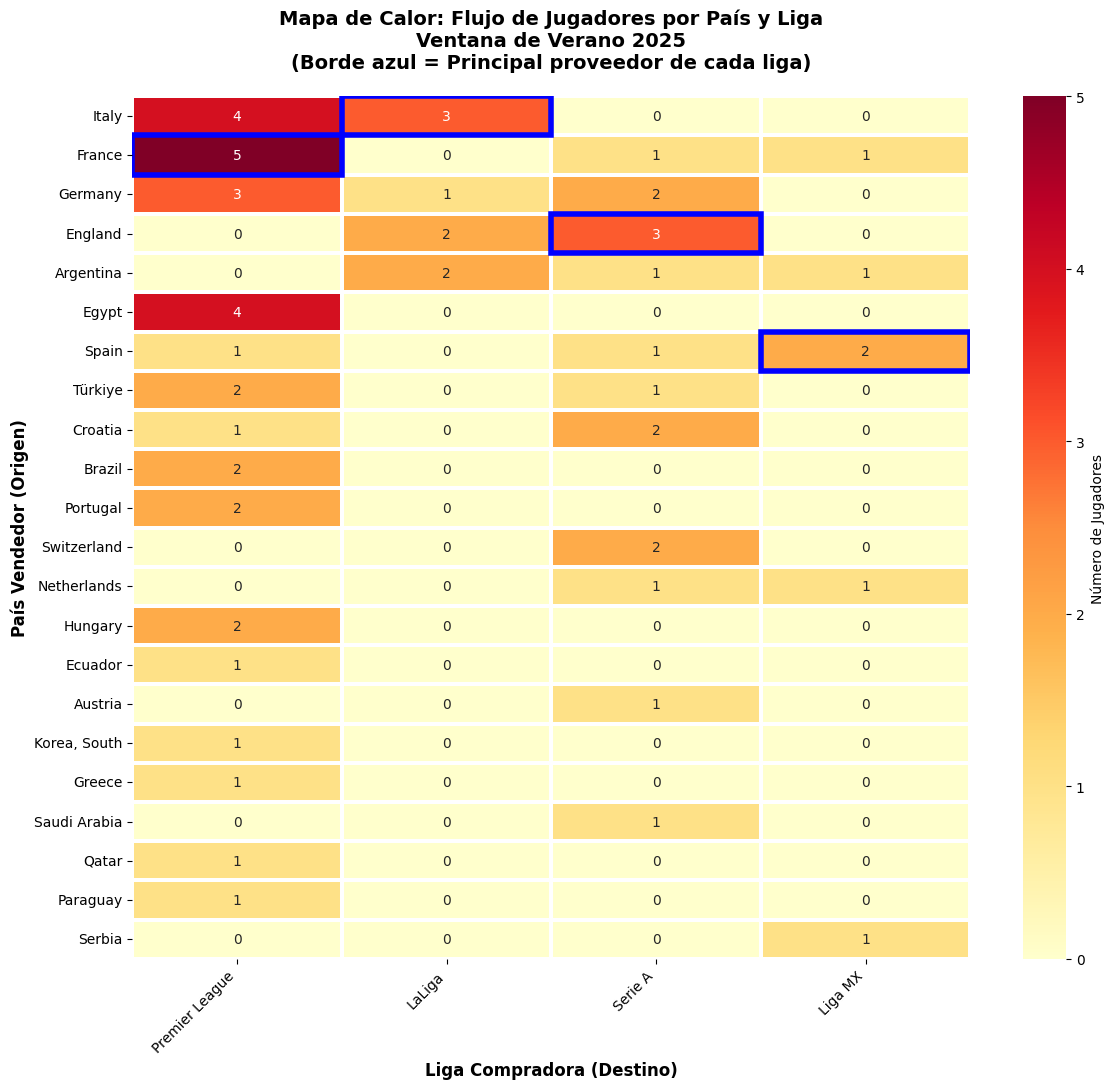

In [ ]:

# Obtener todos los países únicos que aparecen como vendedores
paises_vendedores = set()
for league, home_country in league_countries.items():
    df_foreign = df_fichajes[
        (df_fichajes['Liga_Target'] == league) &
        (df_fichajes['country_from'] != home_country)
    ]
    paises_vendedores.update(df_foreign['country_from'].unique())

paises_vendedores = sorted(list(paises_vendedores))

# Crear matriz de conteo: filas=países, columnas=ligas
matriz_flujos = pd.DataFrame(0, index=paises_vendedores, columns=target_leagues)

# Llenar la matriz con el conteo de jugadores
for league, home_country in league_countries.items():
    df_foreign = df_fichajes[
        (df_fichajes['Liga_Target'] == league) &
        (df_fichajes['country_from'] != home_country)
    ]

    conteo = df_foreign['country_from'].value_counts()
    for pais, cantidad in conteo.items():
        if pais in matriz_flujos.index:
            matriz_flujos.loc[pais, league] = cantidad

# Filtrar países con al menos 1 transferencia (para limpiar la visualización)
matriz_flujos = matriz_flujos[matriz_flujos.sum(axis=1) > 0]

# Ordenar por total de jugadores vendidos (descendente)
matriz_flujos['Total'] = matriz_flujos.sum(axis=1)
matriz_flujos = matriz_flujos.sort_values('Total', ascending=False).drop('Total', axis=1)

# Crear máscara para resaltar los principales proveedores
mascara_principal = pd.DataFrame(False, index=matriz_flujos.index, columns=matriz_flujos.columns)
for liga, pais_principal in df_foreign_suppliers.items():
    if pais_principal != 'N/A' and pais_principal in mascara_principal.index:
        mascara_principal.loc[pais_principal, liga] = True

# Configuración del gráfico
fig, ax = plt.subplots(figsize=(12, max(8, len(matriz_flujos) * 0.5)))

# Crear heatmap
sns.heatmap(matriz_flujos,
            annot=True,  # Mostrar números
            fmt='g',  # Formato de números (sin decimales)
            cmap='YlOrRd',  # Escala de colores (amarillo-naranja-rojo)
            cbar_kws={'label': 'Número de Jugadores'},
            linewidths=1.5,  # Líneas entre celdas
            linecolor='white',
            square=False,
            ax=ax,
            vmin=0)

# Resaltar las celdas del proveedor principal con borde grueso
for liga, pais_principal in df_foreign_suppliers.items():
    if pais_principal != 'N/A' and pais_principal in matriz_flujos.index:
        col_idx = list(matriz_flujos.columns).index(liga)
        row_idx = list(matriz_flujos.index).index(pais_principal)

        # Añadir rectángulo con borde grueso
        rect = plt.Rectangle((col_idx, row_idx), 1, 1,
                            fill=False, edgecolor='blue', linewidth=4)
        ax.add_patch(rect)

# Personalización
ax.set_xlabel('Liga Compradora (Destino)', fontsize=12, fontweight='bold')
ax.set_ylabel('País Vendedor (Origen)', fontsize=12, fontweight='bold')
ax.set_title('Mapa de Calor: Flujo de Jugadores por País y Liga\nVentana de Verano 2025\n(Borde azul = Principal proveedor de cada liga)',
             fontsize=14, fontweight='bold', pad=20)

# Rotar etiquetas para mejor legibilidad
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)

plt.tight_layout()
plt.show()



De las 4 ligas, ¿cuál tiene un perfil de fichaje más consistente en términos de edad?

In [ ]:
big_3_leagues = ['Premier League', 'LaLiga', 'Serie A']
mexican_clubs = [
    'Deportivo Guadalajara', 'Deportivo Toluca', 'Club León FC',
    'Club Necaxa', 'CF Pachuca', 'FC Juárez', 'Puebla FC'
]
ligas_a_comparar = big_3_leagues + ['Liga MX']
EXCLUDE_VALUE = 'without league'

df_limpio = df[df['league_to'] != EXCLUDE_VALUE].copy()

#Crear la columna estandarizada 'Liga_Target' para fichajes (destino)
df_limpio['Liga_Target'] = df_limpio['league_to']
df_limpio.loc[df_limpio['club_to'].isin(mexican_clubs), 'Liga_Target'] = 'Liga MX'

#Filtrar solo las ligas de interés y calcular la Desviación Estándar de la Edad
df_fichajes = df_limpio[df_limpio['Liga_Target'].isin(ligas_a_comparar)]

#Calcular la Desviación Estándar (std) y ordenar de menor a mayor
std_age_by_league = df_fichajes.groupby('Liga_Target')['age'].std().sort_values(ascending=True)

#Imprimir el resultado
print("--- Consistencia de Edad de Fichajes ---")
print("La liga con el valor más bajo es la más consistente.")
print(std_age_by_league.map(lambda x: f'{x:,.2f} años'))

print("\nConclusión:")
liga_mas_consistente = std_age_by_league.index[0]
std_min = std_age_by_league.iloc[0]
print(f"La liga con el perfil de fichaje más consistente en edad es: **{liga_mas_consistente}**, con una desviación estándar de {std_min:,.2f} años.")

--- Consistencia de Edad de Fichajes ---
La liga con el valor más bajo es la más consistente.
Liga_Target
Liga MX           2.83 años
Serie A           3.33 años
Premier League    3.99 años
LaLiga            4.05 años
Name: age, dtype: object

Conclusión:
La liga con el perfil de fichaje más consistente en edad es: **Liga MX**, con una desviación estándar de 2.83 años.


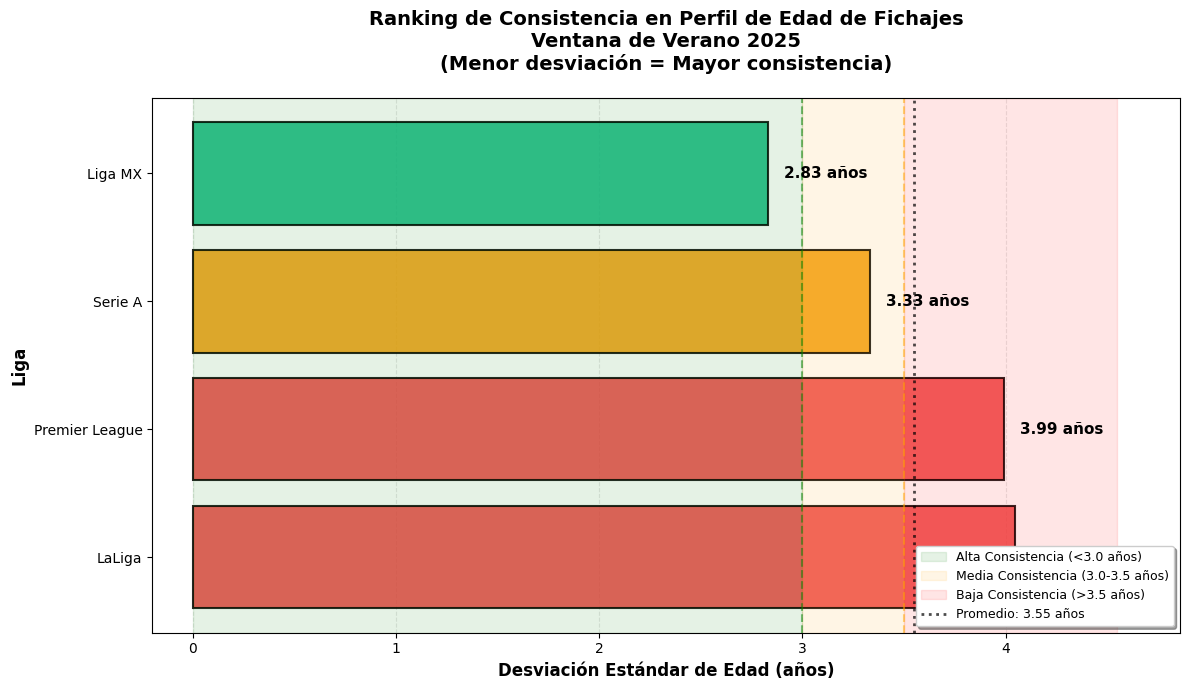

In [ ]:

# Preparar los datos
ligas = std_age_by_league.index.tolist()
desviaciones = std_age_by_league.values

# Definir zonas de consistencia
zona_alta_consistencia = 3.0  # < 3 años = muy consistente
zona_media_consistencia = 3.5  # 3-3.5 años = consistente
# > 3.5 años = variable

# Asignar colores basados en nivel de consistencia
colores = []
for std in desviaciones:
    if std < zona_alta_consistencia:
        colores.append('#10b981')  #Alta consistencia
    elif std < zona_media_consistencia:
        colores.append('#f59e0b')  #Media consistencia
    else:
        colores.append('#ef4444')  #Baja consistencia

# Configuración del gráfico
fig, ax = plt.subplots(figsize=(12, 7))

# Crear barras horizontales
barras = ax.barh(ligas, desviaciones, color=colores, edgecolor='black',
                 linewidth=1.5, alpha=0.85)

# Añadir valores al final de cada barra
for i, (barra, valor) in enumerate(zip(barras, desviaciones)):
    ax.text(valor + 0.08, i, f'{valor:.2f} años',
            va='center', fontsize=11, fontweight='bold')



# Añadir zonas de consistencia con líneas verticales y áreas sombreadas
ax.axvspan(0, zona_alta_consistencia, alpha=0.1, color='green', label='Alta Consistencia (<3.0 años)')
ax.axvspan(zona_alta_consistencia, zona_media_consistencia, alpha=0.1, color='orange', label='Media Consistencia (3.0-3.5 años)')
ax.axvspan(zona_media_consistencia, max(desviaciones) + 0.5, alpha=0.1, color='red', label='Baja Consistencia (>3.5 años)')

# Líneas de referencia
ax.axvline(zona_alta_consistencia, color='green', linestyle='--', linewidth=1.5, alpha=0.5)
ax.axvline(zona_media_consistencia, color='orange', linestyle='--', linewidth=1.5, alpha=0.5)

# Línea del promedio general
promedio_general = desviaciones.mean()
ax.axvline(promedio_general, color='black', linestyle=':', linewidth=2, alpha=0.7, label=f'Promedio: {promedio_general:.2f} años')

# Personalización
ax.set_xlabel('Desviación Estándar de Edad (años)', fontsize=12, fontweight='bold')
ax.set_ylabel('Liga', fontsize=12, fontweight='bold')
ax.set_title('Ranking de Consistencia en Perfil de Edad de Fichajes\nVentana de Verano 2025\n(Menor desviación = Mayor consistencia)',
             fontsize=14, fontweight='bold', pad=20)

# Invertir eje Y para que el #1 esté arriba
ax.invert_yaxis()

# Grid vertical para mejor lectura
ax.grid(axis='x', alpha=0.3, linestyle='--')
ax.set_axisbelow(True)

# Ajustar límites del eje X
ax.set_xlim(-0.2, max(desviaciones) * 1.2)

# Leyenda
ax.legend(loc='lower right', fontsize=9, frameon=True, fancybox=True, shadow=True)

plt.tight_layout()
plt.show()



###Respuesta a pregunta de interés planteada:
###¿Qué diferencias se identifican en el perfil promedio de jugador comprado en 3 de las mejores ligas del mundo en comparación con la liga Mexicana?

In [ ]:
# Definiciones de listas (asumiendo que están definidas)
big_3_leagues = ['Premier League', 'LaLiga', 'Serie A']
mexican_clubs = [
    'Deportivo Guadalajara', 'Deportivo Toluca', 'Club León FC',
    'Club Necaxa', 'CF Pachuca', 'FC Juárez', 'Puebla FC'
]
ligas_a_comparar = big_3_leagues + ['Liga MX']
EXCLUDE_VALUE = 'without league'

# Preparar el DataFrame base (limpieza y asignación de Liga_Target)
df_limpio = df[df['league_to'] != EXCLUDE_VALUE].copy()

# Crear columna estandarizada 'Liga_Target' para fichajes (destino)
df_limpio['Liga_Target'] = df_limpio['league_to']
df_limpio.loc[df_limpio['club_to'].isin(mexican_clubs), 'Liga_Target'] = 'Liga MX'

# Filtrar solo las ligas de interés
df_perfil = df_limpio[df_limpio['Liga_Target'].isin(ligas_a_comparar)].copy()


def get_mean(series):
    return series.mean()

def get_mode(series):
    return series.mode().iloc[0] if not series.mode().empty else 'N/A'


#Calcular el perfil promedio usando agg()
perfil_promedio = df_perfil.groupby('Liga_Target').agg({
    'Liga_Target': 'count',
    'age': get_mean,
    'market_value': get_mean,
    'fee': get_mean,
    'position_group': get_mode,
})

# Renombrar las columnas después
perfil_promedio.columns = [
    'Fichajes Totales',
    'Edad Promedio',
    'Valor Mercado Promedio',
    'Tarifa Promedio (Gasto)',
    'Posición Más Comprada',
]
#Reordenar el DataFrame final
orden_final = ['Premier League', 'LaLiga', 'Serie A', 'Liga MX']
perfil_promedio = perfil_promedio.reindex(orden_final)


#Visualización
def custom_format(val):
    if isinstance(val, (int, float)):
        if val < 100:
            return f'{val:,.1f}'
        else:
            return f'€{val:,.0f}'
    return val

perfil_final_formato = perfil_promedio.map(custom_format)


print("--- PERFIL DE JUGADOR PROMEDIO POR LIGA (Fichajes) ---")
print(perfil_final_formato)

--- PERFIL DE JUGADOR PROMEDIO POR LIGA (Fichajes) ---
               Fichajes Totales Edad Promedio Valor Mercado Promedio  \
Liga_Target                                                            
Premier League             41.0          22.9            €16,352,439   
LaLiga                     17.0          25.5            €15,258,824   
Serie A                    27.0          24.9            €12,148,148   
Liga MX                    10.0          26.7             €2,530,000   

               Tarifa Promedio (Gasto) Posición Más Comprada  
Liga_Target                                                   
Premier League             €16,425,512               Forward  
LaLiga                     €10,617,647              Defender  
Serie A                     €9,456,667            Midfielder  
Liga MX                     €1,316,000               Forward  


/tmp/ipython-input-2345196398.py:172: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


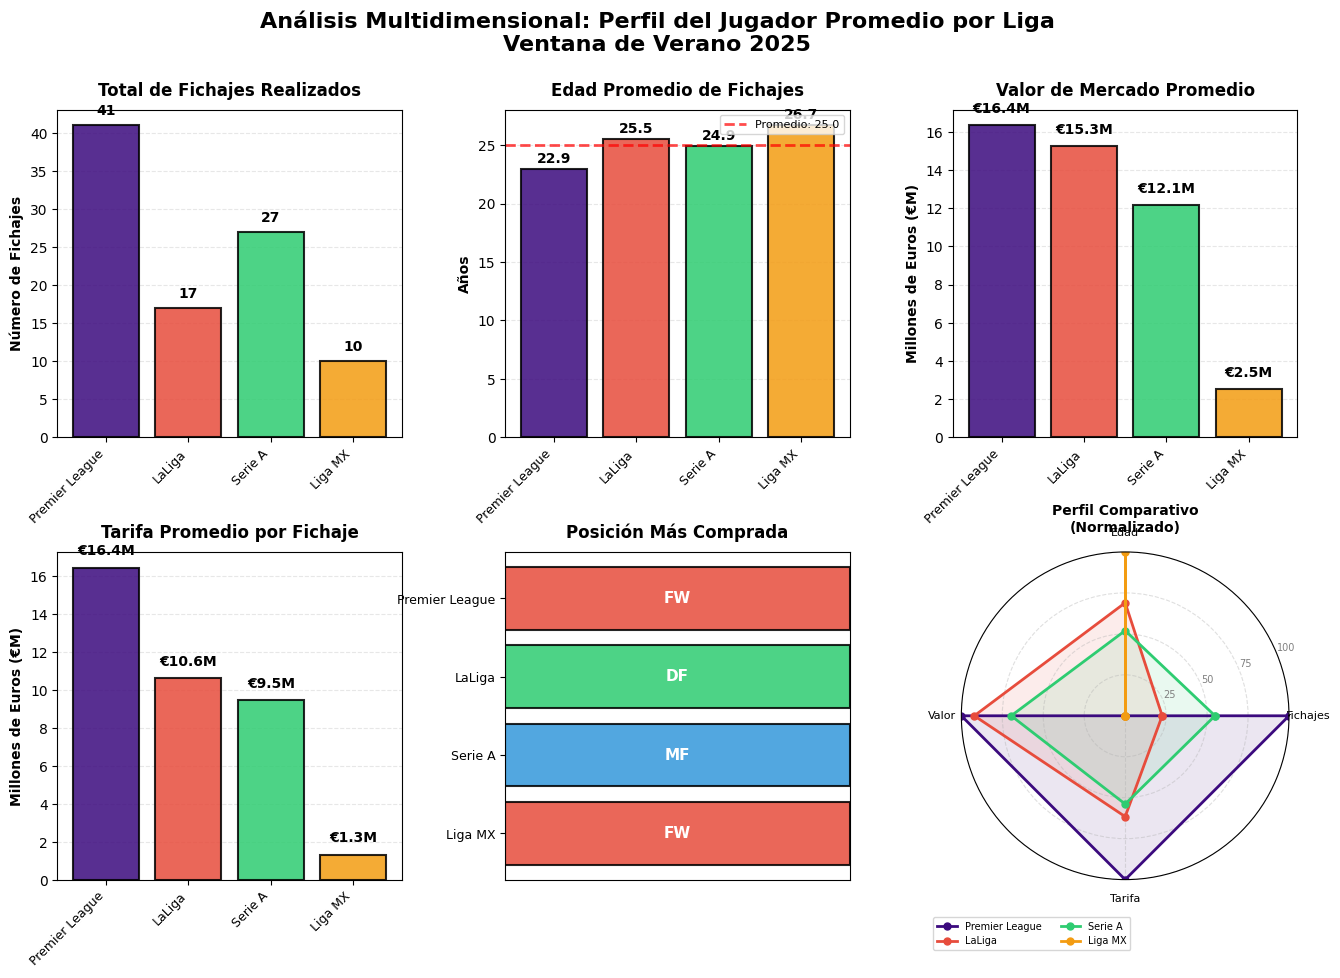

In [ ]:
# Preparar los datos
ligas = perfil_promedio.index.tolist()

# Definir colores consistentes
colores_liga = {
    'Premier League': '#3b0a7e',
    'LaLiga': '#e74c3c',
    'Serie A': '#2ecc71',
    'Liga MX': '#f39c12'
}

colores = [colores_liga[liga] for liga in ligas]

# Crear figura con subplots (2x3 grid)
fig = plt.figure(figsize=(16, 10))
gs = fig.add_gridspec(2, 3, hspace=0.35, wspace=0.3)

# 1. FICHAJES TOTALES
ax1 = fig.add_subplot(gs[0, 0])
fichajes = perfil_promedio['Fichajes Totales'].values
barras1 = ax1.bar(range(len(ligas)), fichajes, color=colores, edgecolor='black', linewidth=1.5, alpha=0.85)

# Añadir valores
for i, (barra, val) in enumerate(zip(barras1, fichajes)):
    ax1.text(i, val + 1, f'{int(val)}', ha='center', va='bottom', fontsize=10, fontweight='bold')

ax1.set_title('Total de Fichajes Realizados', fontsize=12, fontweight='bold', pad=10)
ax1.set_ylabel('Número de Fichajes', fontsize=10, fontweight='bold')
ax1.set_xticks(range(len(ligas)))
ax1.set_xticklabels(ligas, rotation=45, ha='right', fontsize=9)
ax1.grid(axis='y', alpha=0.3, linestyle='--')
ax1.set_axisbelow(True)

#EDAD PROMEDIO
ax2 = fig.add_subplot(gs[0, 1])
edades = perfil_promedio['Edad Promedio'].values
barras2 = ax2.bar(range(len(ligas)), edades, color=colores, edgecolor='black', linewidth=1.5, alpha=0.85)

# Añadir valores
for i, (barra, val) in enumerate(zip(barras2, edades)):
    ax2.text(i, val + 0.3, f'{val:.1f}', ha='center', va='bottom', fontsize=10, fontweight='bold')

# Línea de referencia (promedio)
promedio_edad = edades.mean()
ax2.axhline(promedio_edad, color='red', linestyle='--', linewidth=2, alpha=0.7, label=f'Promedio: {promedio_edad:.1f}')

ax2.set_title('Edad Promedio de Fichajes', fontsize=12, fontweight='bold', pad=10)
ax2.set_ylabel('Años', fontsize=10, fontweight='bold')
ax2.set_xticks(range(len(ligas)))
ax2.set_xticklabels(ligas, rotation=45, ha='right', fontsize=9)
ax2.grid(axis='y', alpha=0.3, linestyle='--')
ax2.set_axisbelow(True)
ax2.legend(fontsize=8, loc='upper right')

#VALOR DE MERCADO PROMEDIO
ax3 = fig.add_subplot(gs[0, 2])
valores_mercado = perfil_promedio['Valor Mercado Promedio'].values / 1_000_000  # Millones
barras3 = ax3.bar(range(len(ligas)), valores_mercado, color=colores, edgecolor='black', linewidth=1.5, alpha=0.85)

# Añadir valores
for i, (barra, val) in enumerate(zip(barras3, valores_mercado)):
    ax3.text(i, val + 0.5, f'€{val:.1f}M', ha='center', va='bottom', fontsize=10, fontweight='bold')

ax3.set_title('Valor de Mercado Promedio', fontsize=12, fontweight='bold', pad=10)
ax3.set_ylabel('Millones de Euros (€M)', fontsize=10, fontweight='bold')
ax3.set_xticks(range(len(ligas)))
ax3.set_xticklabels(ligas, rotation=45, ha='right', fontsize=9)
ax3.grid(axis='y', alpha=0.3, linestyle='--')
ax3.set_axisbelow(True)

#TARIFA PROMEDIO (GASTO)
ax4 = fig.add_subplot(gs[1, 0])
tarifas = perfil_promedio['Tarifa Promedio (Gasto)'].values / 1_000_000  # Millones
barras4 = ax4.bar(range(len(ligas)), tarifas, color=colores, edgecolor='black', linewidth=1.5, alpha=0.85)

# Añadir valores
for i, (barra, val) in enumerate(zip(barras4, tarifas)):
    ax4.text(i, val + 0.5, f'€{val:.1f}M', ha='center', va='bottom', fontsize=10, fontweight='bold')

ax4.set_title('Tarifa Promedio por Fichaje', fontsize=12, fontweight='bold', pad=10)
ax4.set_ylabel('Millones de Euros (€M)', fontsize=10, fontweight='bold')
ax4.set_xticks(range(len(ligas)))
ax4.set_xticklabels(ligas, rotation=45, ha='right', fontsize=9)
ax4.grid(axis='y', alpha=0.3, linestyle='--')
ax4.set_axisbelow(True)

#POSICIÓN MÁS COMPRADA
ax5 = fig.add_subplot(gs[1, 1])

# Contar posiciones
posiciones = perfil_promedio['Posición Más Comprada'].values
posiciones_unicas = list(set(posiciones))

# Crear matriz para stacked bar (aunque en este caso es una sola posición por liga)
pos_to_idx = {pos: i for i, pos in enumerate(posiciones_unicas)}
matriz_pos = np.zeros((len(posiciones_unicas), len(ligas)))

for i, pos in enumerate(posiciones):
    matriz_pos[pos_to_idx[pos], i] = 1

# Iconos o abreviaciones para posiciones
iconos_pos = {
    'Forward': 'FW',
    'Midfielder': 'MF',
    'Defender': 'DF',
    'Goalkeeper': 'GK'
}

# Colores para posiciones
colores_pos = {
    'Forward': '#e74c3c',
    'Midfielder': '#3498db',
    'Defender': '#2ecc71',
    'Goalkeeper': '#f39c12'
}

# Barras horizontales
y_pos = np.arange(len(ligas))
for i, pos in enumerate(posiciones):
    color_pos = colores_pos.get(pos, '#95a5a6')
    icono = iconos_pos.get(pos, pos)
    ax5.barh(y_pos[i], 1, color=color_pos, edgecolor='black', linewidth=1.5, alpha=0.85)
    ax5.text(0.5, y_pos[i], icono, ha='center', va='center', fontsize=11, fontweight='bold', color='white')

ax5.set_title('Posición Más Comprada', fontsize=12, fontweight='bold', pad=10)
ax5.set_yticks(y_pos)
ax5.set_yticklabels(ligas, fontsize=9)
ax5.set_xlim(0, 1)
ax5.set_xticks([])
ax5.invert_yaxis()

#COMPARACIÓN RELATIVA (Radar pequeño)
ax6 = fig.add_subplot(gs[1, 2], projection='polar')

# Métricas para mini-radar
metricas_mini = ['Fichajes', 'Edad', 'Valor', 'Tarifa']
datos_mini = perfil_promedio[['Fichajes Totales', 'Edad Promedio', 'Valor Mercado Promedio', 'Tarifa Promedio (Gasto)']].copy()

# Normalizar a 0-100
datos_norm_mini = datos_mini.copy()
for col in datos_mini.columns:
    min_val = datos_mini[col].min()
    max_val = datos_mini[col].max()
    if max_val - min_val > 0:
        datos_norm_mini[col] = ((datos_mini[col] - min_val) / (max_val - min_val)) * 100
    else:
        datos_norm_mini[col] = 50

num_vars = len(metricas_mini)
angles_mini = [n / float(num_vars) * 2 * np.pi for n in range(num_vars)]
angles_mini += angles_mini[:1]

for i, liga in enumerate(ligas):
    values = datos_norm_mini.iloc[i].tolist()
    values += values[:1]
    ax6.plot(angles_mini, values, 'o-', linewidth=2, label=liga, color=colores_liga[liga], markersize=5)
    ax6.fill(angles_mini, values, alpha=0.1, color=colores_liga[liga])

ax6.set_xticks(angles_mini[:-1])
ax6.set_xticklabels(metricas_mini, size=8)
ax6.set_ylim(0, 100)
ax6.set_yticks([25, 50, 75, 100])
ax6.set_yticklabels(['25', '50', '75', '100'], size=7, color='gray')
ax6.grid(True, linestyle='--', alpha=0.4)
ax6.set_title('Perfil Comparativo\n(Normalizado)', fontsize=10, fontweight='bold', pad=15)
ax6.legend(loc='upper left', bbox_to_anchor=(-0.1, -0.1), fontsize=7, ncol=2)

# TÍTULO GENERAL
fig.suptitle('Análisis Multidimensional: Perfil del Jugador Promedio por Liga\nVentana de Verano 2025',
             fontsize=16, fontweight='bold', y=0.98)

plt.tight_layout()
plt.show()


##Conclusiones:

###Hallazgos:




En base a las preguntas respondidas, los principales hallazgos encontrados son:



*   México fue por diferencia el país que menos invierte y el que menos recibe dinero por ventas de fichajes, en comparación con las 3 ligas Europeas más competitivas del mundo. Por otro lado, Inglaterra que es considerada la liga más fuerte, demostró su amplio poder adquisitivo siendo la liga que más gastó dinero en jugadores. Finalmente, Italia fue la liga que más ingresos generó por ventas de jugadores, sobrepasando por más del doble la cantidad invertida en compras y siendo la única que superó en ventas el dinero gastado.

* Un hallazgo importante a destacar fue que, de los 10 fichajes que se realizaron en la liga mexicana en este dataset, más de la mitad fueron fichajes a países extranjeros. Además de ser el país que promedió la media de edad más alta, lo que significa que México busca mayor mente jugadores veteranos en el extranjero.

* México fue el país que tuvo una menor desviación estándar en cuanto a consistencia de edad en sus fichajes, esto quiere decir que fue la liga que menos variación tuvo en comparación con las 3 ligas más competitivas del mundo.








###Conclusión final:

Es bien sabido que el poder monetario de las ligas europeas, principalmente las ya mencionadas es ampliamente superior al de la liga de primera división mexicana. El análisis ayuda a comprender las dos principales realidades que se viven en Europa y México, pues mientras en el continente Europeo se apuesta principalmente por jugadores jóvenes para asegurar la competitividad en términos de largo plazo, en México se busca un perfil más veterano que rinda principalmente en el corto-mediano plazo, esto podría ser un área de mejora para la liga local, pues si se intentara replicar la fórmula Europea de apostar más por las caras jóvenes, estos al tener un mayor margen de mejora podrían aumentar la competencia con el paso del tiempo y así lograr estar menos alejados de las potencias mundiales en términos futbolísticos.